# DTD + Gemma + MobileNetV3-Small pilot

A Colab-scale proof of concept: sample 517 balanced DTD images, obtain Gemma-based roughness labels through pairwise rankings and Bradley--Terry scoring, then fine-tune one multi-task MobileNetV3-Small model for 47-class texture classification and roughness regression.

This notebook uses official DTD split 1 only. It is a pilot experiment, not a full 10-split DTD benchmark.

In [1]:
%pip install google-genai choix numpy pandas torch torchvision pillow scipy scikit-learn

In [2]:
# Run this cell in Google Colab.
%pip -q install google-genai choix

from google.colab import drive, userdata
drive.mount('/content/drive')

from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/PALM_DTD_Pilot')
RAW_ROOT = PROJECT_ROOT / 'raw'
ARTIFACT_ROOT = PROJECT_ROOT / 'artifacts'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints'
for directory in (RAW_ROOT, ARTIFACT_ROOT, CHECKPOINT_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

GEMMA_MODEL = 'gemma-4-31b-it'  # Keep this aligned with the working Model_Training notebook.
GEMMA_API_KEY = userdata.get('GEMINI_API_KEY')
assert GEMMA_API_KEY, 'Add GOOGLE_API_KEY to Colab Secrets before running Gemma cells.'

PILOT_SEED = 20260809
RANKING_PASSES = 2
DEVICE = 'cuda'  # Colab GPU runtime required.


Mounted at /content/drive


In [3]:
import json
import random
import shutil
import subprocess
import time
from collections import defaultdict

import choix
import numpy as np
import pandas as pd
import torch
from PIL import Image
from google import genai
from google.genai import types
from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

assert torch.cuda.is_available(), 'Enable a Colab GPU runtime before training.'
torch.backends.cudnn.benchmark = True


## 1. Download DTD and build the balanced pilot manifest

The manifest samples 7/2/2 images per class from DTD official split 1's train/validation/test lists, for 517 images total.

In [6]:
def prepare_dtd_pilot_manifest(raw_root, artifact_root, seed=PILOT_SEED):
    """Download DTD once and write a reproducible 7/2/2-per-class pilot manifest."""
    dtd_root = raw_root / 'dtd'
    if not dtd_root.exists():
        archive = raw_root / 'dtd-r1.0.1.tar.gz'
        if archive.exists():
            archive.unlink() # Remove potentially corrupted archive
        if not archive.exists():
            subprocess.run(['wget', '-O', str(archive), 'https://www.robots.ox.ac.uk/~vgg/data/dtd/download/dtd-r1.0.1.tar.gz'], check=True)
        subprocess.run(['tar', '-xzf', str(archive), '-C', str(raw_root)], check=True)

    split_rows = []
    for split_name, count in {'train': 7, 'val': 2, 'test': 2}.items():
        split_file = dtd_root / 'labels' / f'{split_name}1.txt'
        for relative_path in split_file.read_text().splitlines():
            texture_class = relative_path.split('/')[0]
            split_rows.append({'relative_path': relative_path, 'class_name': texture_class, 'split': split_name, 'target_count': count})

    source = pd.DataFrame(split_rows)
    sampled = []
    for class_name, class_rows in source.groupby('class_name', sort=True):
        for split_name, split_rows_for_class in class_rows.groupby('split', sort=False):
            target_count = int(split_rows_for_class['target_count'].iat[0])
            if len(split_rows_for_class) < target_count:
                raise ValueError(f'{class_name}/{split_name} has too few DTD images.')
            deterministic_offset = sum(ord(character) for character in f'{class_name}:{split_name}')
            sampled.append(split_rows_for_class.sample(target_count, random_state=seed + deterministic_offset))

    manifest = pd.concat(sampled, ignore_index=True).drop(columns='target_count')
    classes = sorted(manifest['class_name'].unique())
    manifest['class_index'] = manifest['class_name'].map({name: index for index, name in enumerate(classes)})
    manifest['image_path'] = manifest['relative_path'].map(lambda value: str(dtd_root / 'images' / value))
    manifest = manifest.sort_values(['split', 'class_name', 'relative_path']).reset_index(drop=True)

    expected = {'train': 329, 'val': 94, 'test': 94}
    if manifest['split'].value_counts().to_dict() != expected:
        raise AssertionError(f'Unexpected split sizes: {manifest.split.value_counts().to_dict()}')
    if manifest.groupby('class_name').size().nunique() != 1 or manifest.groupby('class_name').size().iat[0] != 11:
        raise AssertionError('Each DTD class must contribute exactly 11 pilot images.')

    manifest_path = artifact_root / 'dtd_pilot_manifest.csv'
    manifest.to_csv(manifest_path, index=False)
    return manifest, classes

manifest, class_names = prepare_dtd_pilot_manifest(RAW_ROOT, ARTIFACT_ROOT)
manifest.groupby('split').size(), len(class_names)

(split
 test      94
 train    329
 val       94
 dtype: int64,
 47)

In [9]:
def basic_api_test():
    client_test = genai.Client(api_key=GEMMA_API_KEY)
    interaction = client_test.models.generate_content(
        model="gemini-3.6-flash",
        contents="Explain how AI works in a few words"
    )
    print(interaction.text)

    print(f"Prompt Tokens: {interaction.usage_metadata.prompt_token_count}")
    print(f"Output Tokens: {interaction.usage_metadata.candidates_token_count}")
    print(f"Total Tokens: {interaction.usage_metadata.total_token_count}")
basic_api_test()

**AI learns patterns from vast amounts of data to make predictions, solve problems, and make decisions.** 

In three simple steps:
1. **Data in:** It consumes information.
2. **Patterns found:** It spots connections and rules.
3. **Output made:** It predicts the best answer based on what it learned.
Prompt Tokens: 9
Output Tokens: 69
Total Tokens: 495


## 2. Gemma rankings with resumable bridge batches

The code below borrows the prior notebook's JSON-only ranking prompt, randomized labels, retry behavior, and validation. Bridge images make all ranking groups part of one connected Bradley--Terry graph.

In [11]:
def rank_images_gemma(image_paths, labels, client, model=GEMMA_MODEL):
    """Borrowed/adapted from Model_Training.ipynb; returns labels smoothest to roughest."""
    prompt = (
        'You will see five texture images, each preceded by a label. Rank them from smoothest to roughest '
        'based only on visible surface microtexture. Ignore brightness, color, object identity, and image sharpness. '
        'Use grain, fibers, bumps, irregular edges, and fine spatial variation as evidence. '
        'Respond ONLY with a JSON array containing each label exactly once, from smoothest to roughest.'
        ' e.g. [\"C\", \"A\", \"E\", \"B\", \"D\"]. No other text.'
    )
    parts = [types.Part.from_text(text=prompt)]
    for label, image_path in zip(labels, image_paths):
        parts.append(types.Part.from_text(text=f'Image {label}:'))
        parts.append(types.Part.from_bytes(data=Path(image_path).read_bytes(), mime_type='image/jpeg'))
    response = client.models.generate_content(
        model=model, contents=parts,
        config=types.GenerateContentConfig(temperature=0.1, response_mime_type='application/json', response_schema=list[str]),
    )

    # Defensive JSON parsing: try to extract the JSON array even if there's extra text
    response_text = response.text.strip()
    try:
        ranked_labels = json.loads(response_text)
    except json.JSONDecodeError as e:
        # Attempt to find and parse the JSON array if extra data is present
        start_brace = response_text.find('[')
        end_brace = response_text.rfind(']')
        if start_brace != -1 and end_brace != -1 and start_brace < end_brace:
            json_substring = response_text[start_brace : end_brace + 1]
            try:
                ranked_labels = json.loads(json_substring)
                print(f"Warning: JSONDecodeError fixed by extracting substring. Original error: {e}")
            except json.JSONDecodeError:
                # If extraction still fails, re-raise the original error
                raise e
        else:
            # If no JSON array braces are found, re-raise the original error
            raise e

    if sorted(ranked_labels) != sorted(labels):
        raise ValueError(f'Gemma returned an incomplete or duplicate ranking: {ranked_labels}')
    return ranked_labels

def rank_with_retry(image_paths, labels, client, max_retries=6, base_wait_seconds=20):
    for attempt in range(max_retries):
        try:
            return rank_images_gemma(image_paths, labels, client)
        except Exception as error:
            if attempt == max_retries - 1:
                raise
            wait_seconds = base_wait_seconds * (2 ** attempt)
            print(f'Gemma attempt {attempt + 1} failed ({error}); retrying in {wait_seconds}s.')
            time.sleep(wait_seconds)

def make_bridge_groups(image_paths, passes=RANKING_PASSES, seed=PILOT_SEED):
    """Create connected 5-image groups: five bridge images plus four targets per group."""
    image_paths = [str(path) for path in image_paths]
    bridges = image_paths[:5]
    targets = image_paths[5:]
    all_groups = []
    for pass_index in range(passes):
        rng = random.Random(seed + pass_index)
        shuffled_targets = targets.copy()
        rng.shuffle(shuffled_targets)
        all_groups.append({'pass_index': pass_index, 'group_index': 0, 'image_paths': bridges})
        for group_index, offset in enumerate(range(0, len(shuffled_targets), 4), start=1):
            group = [bridges[(group_index - 1) % len(bridges)]] + shuffled_targets[offset:offset + 4]
            if len(group) == 5:
                all_groups.append({'pass_index': pass_index, 'group_index': group_index, 'image_paths': group})
    return all_groups

def collect_gemma_rankings(manifest, artifact_root):
    output_path = artifact_root / 'gemma_dtd_pilot_rankings.json'
    completed = json.loads(output_path.read_text()) if output_path.exists() else []
    completed_keys = {(row['pass_index'], row['group_index']) for row in completed}
    client = genai.Client(api_key=GEMMA_API_KEY)

    groups = make_bridge_groups(manifest['image_path'].tolist())
    for group in groups:
        key = (group['pass_index'], group['group_index'])
        if key in completed_keys:
            continue
        shuffled_paths = group['image_paths'].copy()
        random.Random(PILOT_SEED + group['pass_index'] * 10_000 + group['group_index']).shuffle(shuffled_paths)
        labels = [chr(65 + index) for index in range(5)]
        ranked_labels = rank_with_retry(shuffled_paths, labels, client)
        label_to_path = dict(zip(labels, shuffled_paths))
        completed.append({**group, 'ranked_image_paths': [label_to_path[label] for label in ranked_labels]})
        output_path.write_text(json.dumps(completed, indent=2))
        print(f'Completed {len(completed)}/{len(groups)} groups.')
        time.sleep(20)
    return completed

# Run once for the full resumable Gemma labeling job.
gemma_rankings = collect_gemma_rankings(manifest, ARTIFACT_ROOT)

Completed 2/258 groups.
Completed 3/258 groups.
Completed 4/258 groups.
Completed 5/258 groups.
Completed 6/258 groups.
Completed 7/258 groups.
Completed 8/258 groups.
Completed 9/258 groups.
Completed 10/258 groups.
Completed 11/258 groups.
Completed 12/258 groups.
Completed 13/258 groups.
Completed 14/258 groups.
Completed 15/258 groups.
Completed 16/258 groups.
Completed 17/258 groups.
Completed 18/258 groups.
Completed 19/258 groups.
Completed 20/258 groups.
Completed 21/258 groups.
Completed 22/258 groups.
Completed 23/258 groups.
Completed 24/258 groups.
Completed 25/258 groups.
Completed 26/258 groups.
Completed 27/258 groups.
Completed 28/258 groups.
Completed 29/258 groups.
Completed 30/258 groups.
Gemma attempt 1 failed (503 UNAVAILABLE. {'error': {'code': 503, 'message': 'Deadline expired before operation could complete.', 'status': 'UNAVAILABLE'}}); retrying in 20s.
Completed 31/258 groups.
Completed 32/258 groups.
Completed 33/258 groups.
Completed 34/258 groups.
Completed

In [ ]:
gemma_rankings

In [15]:
def fit_roughness_labels(manifest, artifact_root):
    """Fit BT smoothness, invert it, and save normalized roughness labels in [0, 1]."""
    ranking_path = artifact_root / 'gemma_dtd_pilot_rankings.json'
    rankings = json.loads(ranking_path.read_text())
    image_paths = manifest['image_path'].tolist()
    image_to_id = {image_path: index for index, image_path in enumerate(image_paths)}
    comparisons = []
    for ranking in rankings:
        ordered = ranking['ranked_image_paths']  # smoothest first
        for position, winner in enumerate(ordered):
            for loser in ordered[position + 1:]:
                comparisons.append((image_to_id[winner], image_to_id[loser]))
    if not comparisons:
        raise ValueError('No Gemma rankings found. Run collect_gemma_rankings first.')
    smoothness = choix.ilsr_pairwise(len(image_paths), comparisons, alpha=0.01)
    roughness = -smoothness
    roughness = (roughness - roughness.min()) / (roughness.max() - roughness.min())
    labels = manifest.copy()
    labels['gemma_bt_roughness'] = roughness
    labels_path = artifact_root / 'dtd_pilot_gemma_bt_labels.csv'
    labels.to_csv(labels_path, index=False)
    return labels

labeled_manifest = fit_roughness_labels(manifest, ARTIFACT_ROOT)


## 3. Multi-task MobileNetV3-Small

Run after `dtd_pilot_gemma_bt_labels.csv` has been created. Five seeds give a compact estimate of training variability without treating this pilot as a full DTD benchmark.

In [16]:
class DTDPilotDataset(Dataset):
    def __init__(self, rows, transform):
        self.rows = rows.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, index):
        row = self.rows.iloc[index]
        image = self.transform(Image.open(row.image_path).convert('RGB'))
        return image, int(row.class_index), torch.tensor(float(row.gemma_bt_roughness), dtype=torch.float32)

class MultiTaskMobileNetV3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        feature_count = backbone.classifier[0].in_features
        backbone.classifier = nn.Identity()
        self.backbone = backbone
        self.classification_head = nn.Linear(feature_count, num_classes)
        self.roughness_head = nn.Linear(feature_count, 1)
    def forward(self, images):
        features = self.backbone(images)
        return self.classification_head(features), self.roughness_head(features).squeeze(1)

def make_loaders(labeled_manifest, batch_size=32):
    normalization = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    train_transform = transforms.Compose([transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(), transforms.ColorJitter(0.15, 0.15, 0.1, 0.03), transforms.ToTensor(), normalization])
    evaluation_transform = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), normalization])
    loaders = {}
    for split in ('train', 'val', 'test'):
        rows = labeled_manifest[labeled_manifest.split == split]
        dataset = DTDPilotDataset(rows, train_transform if split == 'train' else evaluation_transform)
        loaders[split] = DataLoader(dataset, batch_size=batch_size, shuffle=split == 'train', num_workers=2, pin_memory=True)
    return loaders

def evaluate_model(model, loader):
    model.eval();
    actual_roughness, predicted_roughness = [], []
    with torch.no_grad():
        for images, labels, roughness in loader:
            # We still need to call the model with both heads, but we will only use roughness_prediction
            class_logits, roughness_prediction = model(images.to(DEVICE))
            actual_roughness.extend(roughness.numpy()); predicted_roughness.extend(roughness_prediction.cpu().numpy())
    return {'spearman_r': spearmanr(actual_roughness, predicted_roughness).statistic, 'mae': mean_absolute_error(actual_roughness, predicted_roughness), 'rmse': mean_squared_error(actual_roughness, predicted_roughness) ** 0.5}

In [17]:
def train_one_seed(labeled_manifest, seed, roughness_loss_weight=1.0, warmup_epochs=3, max_epochs=25, patience=5):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    loaders = make_loaders(labeled_manifest)
    model = MultiTaskMobileNetV3(labeled_manifest.class_index.nunique()).to(DEVICE)
    # Freeze backbone for initial warmup, and also freeze classification head.
    for parameter in model.backbone.parameters():
        parameter.requires_grad = False
    for parameter in model.classification_head.parameters():
        parameter.requires_grad = False
    # Only optimize the roughness head initially
    optimizer = torch.optim.AdamW(model.roughness_head.parameters(), lr=3e-4, weight_decay=1e-4)

    # Classification loss is no longer used
    regression_loss = nn.SmoothL1Loss()
    best_state, best_validation_loss, stale_epochs = None, float('inf'), 0
    for epoch in range(max_epochs):
        if epoch == warmup_epochs:
            # Unfreeze backbone parameters after warmup (if needed for regression improvement)
            # and include them in the optimizer. The classification head remains frozen/unused.
            for parameter in model.backbone.parameters():
                parameter.requires_grad = True
            optimizer = torch.optim.AdamW(list(model.backbone.parameters()) + list(model.roughness_head.parameters()), lr=3e-4, weight_decay=1e-4)

        model.train(); running_loss = 0.0
        for images, labels, roughness in loaders['train']:
            optimizer.zero_grad()
            class_logits, roughness_prediction = model(images.to(DEVICE)) # Still call both heads
            loss = roughness_loss_weight * regression_loss(roughness_prediction, roughness.to(DEVICE))
            loss.backward(); optimizer.step(); running_loss += loss.item()

        validation = evaluate_model(model, loaders['val'])
        # Validation loss is now based purely on regression metrics
        validation_loss = validation['mae'] # Using MAE for early stopping

        if validation_loss < best_validation_loss:
            best_validation_loss, stale_epochs = validation_loss, 0
            best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                break
    model.load_state_dict(best_state)
    checkpoint_path = CHECKPOINT_ROOT / f'mobilenetv3_pilot_seed_{seed}.pt'
    torch.save({'seed': seed, 'model_state_dict': model.state_dict(), 'classes': class_names}, checkpoint_path)
    return {'seed': seed, 'epochs_completed': epoch + 1, **evaluate_model(model, loaders['test'])}

labeled_manifest = pd.read_csv(ARTIFACT_ROOT / 'dtd_pilot_gemma_bt_labels.csv')
seed_results = pd.DataFrame([train_one_seed(labeled_manifest, PILOT_SEED + seed_offset) for seed_offset in range(5)])
seed_results.to_csv(ARTIFACT_ROOT / 'mobilenetv3_pilot_test_metrics.csv', index=False)
display(seed_results)
display(seed_results.drop(columns=['seed', 'epochs_completed']).agg(['mean', 'std']).T)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 104MB/s]


,seed,epochs_completed,accuracy,macro_f1,spearman_r,mae,rmse
0,20260809,25,0.372340,0.351709,0.230372,0.209934,0.254816
1,20260810,25,0.425532,0.390763,0.434729,0.212160,0.269073
2,20260811,19,0.308511,0.270365,0.154095,0.240225,0.310561
3,20260812,14,0.319149,0.288636,0.023906,0.245447,0.309065
4,20260813,25,0.404255,0.376461,0.137781,0.204269,0.256371


,mean,std
accuracy,0.365957,0.051351
macro_f1,0.335587,0.053463
spearman_r,0.196177,0.152426
mae,0.222407,0.018960
rmse,0.279977,0.027797


### Analyzing the Roughness Label Distribution

First, let's visualize the distribution of the `gemma_bt_roughness` labels. A highly skewed or concentrated distribution could make the regression task more challenging.

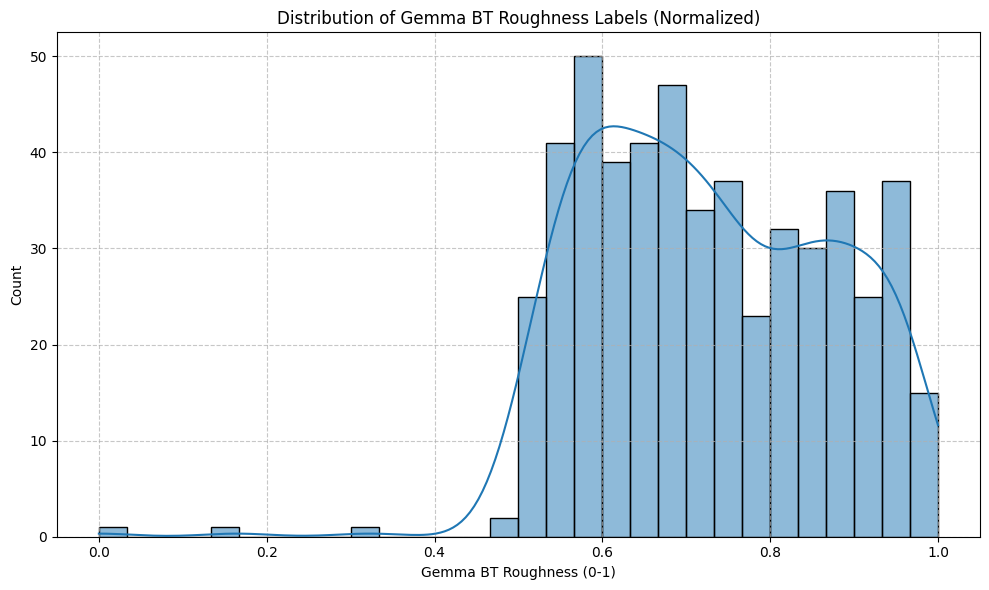

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of gemma_bt_roughness labels
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(labeled_manifest['gemma_bt_roughness'], bins=30, kde=True, ax=ax)
ax.set_title('Distribution of Gemma BT Roughness Labels (Normalized)')
ax.set_xlabel('Gemma BT Roughness (0-1)')
ax.set_ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Further Diagnostic Steps and Potential Issues

Beyond the roughness label distribution, here are further steps and potential reasons for the low performance:

1.  **Learning Curves**: To understand if the model is learning, overfitting, or underfitting, we need to track training and validation loss/metrics per epoch. The `train_one_seed` function currently only returns final test metrics. We could modify it to store and return a history of metrics.

2.  **Predicted vs. Actual Roughness Plot**: A scatter plot of predicted roughness against actual roughness on the test set would reveal the quality of the regression. We could modify `evaluate_model` to return the predictions along with the metrics.

3.  **Classification Confusion Matrix**: For the classification task, a confusion matrix on the test set would show which classes are being misclassified, and if certain classes are consistently confused with others.

4.  **Gemma Label Quality**: The `Warning: JSONDecodeError fixed by extracting substring` messages during Gemma ranking suggest some instability in Gemma's output format. While the fix extracts the JSON, there might still be subtle inconsistencies or noise in the actual rankings that make the labels difficult to learn.

5.  **Model Capacity**: MobileNetV3-Small might be too small for this challenging multi-task problem (47-class classification + roughness regression on subtle texture differences).

6.  **Hyperparameters**: The current learning rate, weight decay, `max_epochs`, `patience`, and `roughness_loss_weight` might not be optimal. Tuning these could significantly improve performance.

7.  **Data Scale/Complexity**: 517 images is a relatively small dataset for training a deep learning model from scratch (even with a pre-trained backbone). The subtle differences in 'roughness' of textures might be very hard for the model to discern.

I recommend we first analyze the roughness distribution plot generated above. If you'd like to proceed with gathering more diagnostic data during training (learning curves, predictions), we would need to modify the `train_one_seed` and `evaluate_model` functions.